# Stage 4: RL LOD Policy Training - REINFORCE (Audit-Aligned)

Trains the Stage 4 policy on real `rollout_ep*.csv` files collected by `RLRolloutLogger`.
Exports `rl_policy_stage4.onnx` consumed by `RLPolicyController` and
`rl_scaler_constants.json` consumed by `RLFeatureExtractor`.

This notebook now applies the Stage 4 audit fixes directly:
- fails fast if native rollout files are missing or near-degenerate
- uses episode/file-group holdout instead of row-wise splitting
- matches the deployable action envelope (`[-0.20, +0.20]`) used by `RLPolicyController`
- tracks deployable action quality with dead-zone / dwell / clamp simulation diagnostics

**Input**: `ml_pipeline/data/RL/Train/RLRollouts/rollout_ep*.csv`
**Output**: `ml_pipeline/models/Stage_4/rl_policy_stage4.onnx` + `rl_scaler_constants.json`

### Feature order (must match `RLFeatureExtractor.ExpectedFeatureNames` exactly)
| idx | name | notes |
|-----|------|-------|
| 0 | cpu_frame_time | ms - diagnostic only |
| 1 | gpu_frame_time | ms - reward signal source |
| 2 | fps | 1/deltaTime |
| 3 | visible_renderer_count | frustum sweep, not URP profiler |
| 4 | triangle_count | profiler recorder |
| 5 | draw_call_count | profiler recorder |
| 6 | camera_speed | m/s |
| 7 | camera_rotation_speed | deg/s |
| 8 | avg_screen_coverage | SSIM proxy |
| 9 | previous_bias | lodBias prior frame |
| 10 | recent_lod_switch_count | ring buffer count |

### Reward formula (matches `RLEvaluationLogger`)
```
r_t = (gpu_prev - gpu_t) + BONUS_SCALE * (gpu_t <= T_TARGET)
```


In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sympy==1.12', 'optuna', '--quiet'])
print('Dependencies OK')

Dependencies OK


In [2]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
BASE_DIR        = Path('../..').resolve()
DATA_DIR        = BASE_DIR / 'data' / 'RL' / 'Train' / 'RLRollouts'
MODEL_DIR       = BASE_DIR / 'models' / 'Stage_4'
PLOTS_DIR       = BASE_DIR / 'plots' / 'Stage_4' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Reward: improvement-based (matches RLEvaluationLogger)
T_TARGET         = 4.5
BONUS_SCALE      = 1.0
REWARD_CLIP      = 5.0
GPU_VALID_MIN_MS = 0.10
GPU_VALID_MAX_MS = 33.3

# Runtime guardrails (must match Unity deployment)
DEAD_ZONE        = 0.02
DWELL_FRAMES     = 5
BIAS_MIN         = 0.30
BIAS_MAX         = 2.00

# Legacy weights (not used in reward; retained for report parity)
ALPHA            = 1.0
BETA             = 0.5
GAMMA_W          = 0.0
N_MAX            = 30.0

# REINFORCE / rollout-policy training hyperparameters
GAMMA_RL           = 0.99
TRAIN_SIGMA        = 0.10
ACTION_HEAD_SCALE  = 0.20
PG_COEF            = 0.75
BC_COEF_START      = 0.12
BC_COEF_END        = 0.02
NONZERO_BC_WEIGHT  = 2.5
SUPPORT_MARGIN     = 0.02
SUPPORT_COEF_START = 0.25
SUPPORT_COEF_END   = 0.00
SAT_WARN_THRESHOLD = ACTION_HEAD_SCALE - 0.01
SAT_COEF           = 2.0
ENTROPY_COEF       = 0.02
POS_SAT_COEF       = 4.0
VAL_GROUP_FRAC     = 0.20
GRAD_CLIP          = 1.0
BATCH_SIZE         = 256
RANDOM_SEED        = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

FEATURE_COUNT = 11
FEATURE_COLS  = [
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count'
]

print(f'Device:              {device}')
print(f'DATA_DIR:            {DATA_DIR}')
print(f'TRAIN_SIGMA:         {TRAIN_SIGMA:.3f}')
print(f'ACTION_HEAD_SCALE:   {ACTION_HEAD_SCALE:.3f}')
print(f'PG_COEF:             {PG_COEF:.2f}')
print(f'BC_COEF schedule:    {BC_COEF_START:.2f} -> {BC_COEF_END:.2f}')
print(f'SUPPORT_COEF sched:  {SUPPORT_COEF_START:.2f} -> {SUPPORT_COEF_END:.2f}')
print(f'ENTROPY_COEF:        {ENTROPY_COEF:.4f}')
print(f'SAT_WARN_THRESHOLD:  {SAT_WARN_THRESHOLD:.3f}')
print(f'Runtime guardrails:  dead_zone={DEAD_ZONE:.2f} dwell={DWELL_FRAMES} bias=[{BIAS_MIN:.2f}, {BIAS_MAX:.2f}]')
print(f'GPU valid ms:        [{GPU_VALID_MIN_MS:.2f}, {GPU_VALID_MAX_MS:.1f}]')


Device:              cuda
DATA_DIR:            C:\Users\Gica\neural-lod\ml_pipeline\data\RL\Train\RLRollouts
TRAIN_SIGMA:         0.100
ACTION_HEAD_SCALE:   0.200
PG_COEF:             0.75
BC_COEF schedule:    0.12 -> 0.02
SUPPORT_COEF sched:  0.25 -> 0.00
ENTROPY_COEF:        0.0200
SAT_WARN_THRESHOLD:  0.190
Runtime guardrails:  dead_zone=0.02 dwell=5 bias=[0.30, 2.00]
GPU valid ms:        [0.10, 33.3]


## 1. Load Rollout CSVs
Reads `rollout_ep*.csv` files produced by `RLRolloutLogger`.
Audit guardrail: Stage 4 training now fails fast if native rollout files are missing.


In [4]:
REQUIRED_ROLLOUT_COLUMNS = {
    'episode',
    'step',
    *FEATURE_COLS,
    'lod_bias_before_action',
    'action_delta',
    'lod_bias_after_action'
}

rollout_files = sorted(DATA_DIR.glob('rollout_ep*.csv'))
print(f'rollout_ep*.csv: {len(rollout_files)}')

if not rollout_files:
    raise FileNotFoundError(
        'Stage 4 training now requires native rollout_ep*.csv files.\n'
        'Audit findings block training_data_*.csv / inference_eval_*.csv fallbacks.\n'
        f'Expected files under: {DATA_DIR}'
    )

dfs = []
for f in rollout_files:
    df = pd.read_csv(f)
    missing = sorted(REQUIRED_ROLLOUT_COLUMNS.difference(df.columns))
    if missing:
        raise ValueError(f'{f.name} is missing required rollout columns: {missing}')
    df['source_file'] = f.name
    dfs.append(df)

raw = pd.concat(dfs, ignore_index=True)

all_cols = [
    'episode', 'step', 'cpu_frame_time', 'gpu_frame_time', 'fps',
    'visible_renderer_count', 'triangle_count', 'draw_call_count',
    'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
    'previous_bias', 'recent_lod_switch_count',
    'lod_bias_before_action', 'action_delta', 'lod_bias_after_action'
]
for col in all_cols:
    raw[col] = pd.to_numeric(raw[col], errors='coerce')

print(f'Raw rows   : {len(raw):,}')
print(f'Episodes   : {raw["episode"].nunique()}')
print(f'Files      : {raw["source_file"].nunique()}')
print(f'Steps / ep : {raw.groupby("episode").size().mean():.0f}')

if raw['source_file'].nunique() < 2 and raw['episode'].nunique() < 2:
    raise ValueError(
        'Need at least 2 rollout files or 2 episodes for an audit-safe holdout split. '
        f'Found files={raw["source_file"].nunique()} episodes={raw["episode"].nunique()}.'
    )

print('\nRows per rollout file:')
display(raw.groupby('source_file').size().sort_values().to_frame('rows'))
raw.head(3)


rollout_ep*.csv: 11
Raw rows   : 10,240
Episodes   : 5
Files      : 11
Steps / ep : 2048

Rows per rollout file:


,rows
source_file,
rollout_ep0003_20260404_195324.csv,254
rollout_ep0004_20260404_195522.csv,770
rollout_ep0000_20260404_195201.csv,1024
rollout_ep0000_20260404_195342.csv,1024
rollout_ep0001_20260404_195408.csv,1024
rollout_ep0001_20260404_195625.csv,1024
rollout_ep0000_20260404_195559.csv,1024
rollout_ep0001_20260404_195231.csv,1024
rollout_ep0002_20260404_195433.csv,1024


,episode,step,cpu_frame_time,gpu_frame_time,fps,visible_renderer_count,triangle_count,draw_call_count,camera_speed,camera_rotation_speed,avg_screen_coverage,previous_bias,recent_lod_switch_count,lod_bias_before_action,action_delta,lod_bias_after_action,source_file
0,0,0,32.4225,6.1768,0.0,0,0,0,0.0,0.0,0.000000,0.0,0,1.0,0.0,1.0,rollout_ep0000_20260404_195201.csv
1,0,1,0.8182,7.9196,0.0,0,0,0,0.0,0.0,0.000000,0.0,0,1.0,0.0,1.0,rollout_ep0000_20260404_195201.csv
2,0,2,35.4773,6.1870,50.0,17716,376613,2561,0.0,0.0,0.002837,2.0,1,1.0,0.0,1.0,rollout_ep0000_20260404_195201.csv


make sure the data loaded is compatible

In [5]:
# AFTER concatenating dfs into raw

raw = pd.concat(dfs, ignore_index=True)

# =========================
# FIX: REBUILD EPISODES
# =========================
if raw['episode'].isna().all():
    print("Fixing missing episode column...")

    # create episode from step reset
    raw['episode'] = (raw['step'] == 0).cumsum()

    # fallback if no reset exists
    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes after fix:", raw['episode'].nunique())

Episodes after fix: 5


## 2. Data Cleaning
Remove corrupt or warmup frames using the same GPU validity window implied by the Stage 4 docs and scripts.
Bootstrap rollouts are expected to be quantized because `RLPolicyController` applies a dead zone and dwell guard before logging `action_delta`.

In [6]:
# Remove invalid / corrupt timing rows
# Audit guardrail: fail fast on degenerate training features instead of training through them.
df_clean = raw[
    (raw['cpu_frame_time'] > 0) &
    (raw['gpu_frame_time'] >= GPU_VALID_MIN_MS) &
    (raw['gpu_frame_time'] <= GPU_VALID_MAX_MS)
].copy()

print(f'After timing filter: {len(df_clean):,} rows ({100 * len(df_clean) / len(raw):.1f}% kept)')

if len(df_clean) == 0:
    raise ValueError('All rows removed by timing filter -- check rollout collection')

df_clean = df_clean.dropna(subset=FEATURE_COLS + ['action_delta']).copy()
print(f'After NaN drop:      {len(df_clean):,} rows')

if len(df_clean) == 0:
    raise ValueError('All rows removed after NaN drop')

a = pd.to_numeric(df_clean['action_delta'], errors='coerce').fillna(0).astype('float32')
action_counts = a.value_counts().sort_index()

print('Observed rollout action distribution:')
print(action_counts.to_string())
print(f'Non-zero action % : {(a.abs() > 1e-6).mean() * 100:.1f}')
print(f'Near-zero action %: {(a.abs() < 0.005).mean() * 100:.1f}')

feature_nonzero = (df_clean[FEATURE_COLS] != 0).mean() * 100
print('\nFeature non-zero % after timing filter:')
print(feature_nonzero.to_string())

bad_features = feature_nonzero[feature_nonzero < 1.0]
if len(bad_features):
    lines = [f'  {name}: {pct:.2f}% non-zero' for name, pct in bad_features.items()]
    raise ValueError(
        'Audit guardrail tripped: near-all-zero Stage 4 features remain after cleaning:\n' +
        '\n'.join(lines)
    )

ep_stats = df_clean.groupby('episode').agg(
    steps=('step', 'count'),
    mean_gpu=('gpu_frame_time', 'mean'),
    mean_fps=('fps', 'mean'),
    mean_bias=('lod_bias_after_action', 'mean')
).round(3)
print(f'Episode summary ({len(ep_stats)} episodes):')
display(ep_stats.head(10))


After timing filter: 10,237 rows (100.0% kept)
After NaN drop:      10,237 rows
Observed rollout action distribution:
action_delta
-0.05     642
 0.00    9064
 0.05     531
Non-zero action % : 11.5
Near-zero action %: 88.5

Feature non-zero % after timing filter:
cpu_frame_time             100.000000
gpu_frame_time             100.000000
fps                         99.951158
visible_renderer_count      99.951158
triangle_count              99.951158
draw_call_count             99.951158
camera_speed                57.370323
camera_rotation_speed       46.234248
avg_screen_coverage         99.951158
previous_bias               99.951158
recent_lod_switch_count     98.612875
Episode summary (5 episodes):


,steps,mean_gpu,mean_fps,mean_bias
episode,,,,
0,3069,6.771,61.187,0.822
1,3072,6.586,60.743,0.535
2,2048,6.021,59.760,0.718
3,1278,6.073,55.946,0.663
4,770,6.276,53.056,0.443


## 3. Feature Scaling
Fit `StandardScaler` on the 11-feature state vector and save `rl_scaler_constants.json`.  
Copy this JSON to `Assets/StreamingAssets/` for `RLFeatureExtractor` to load at runtime.

Scaling OK: (10237, 11)
Saved: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json


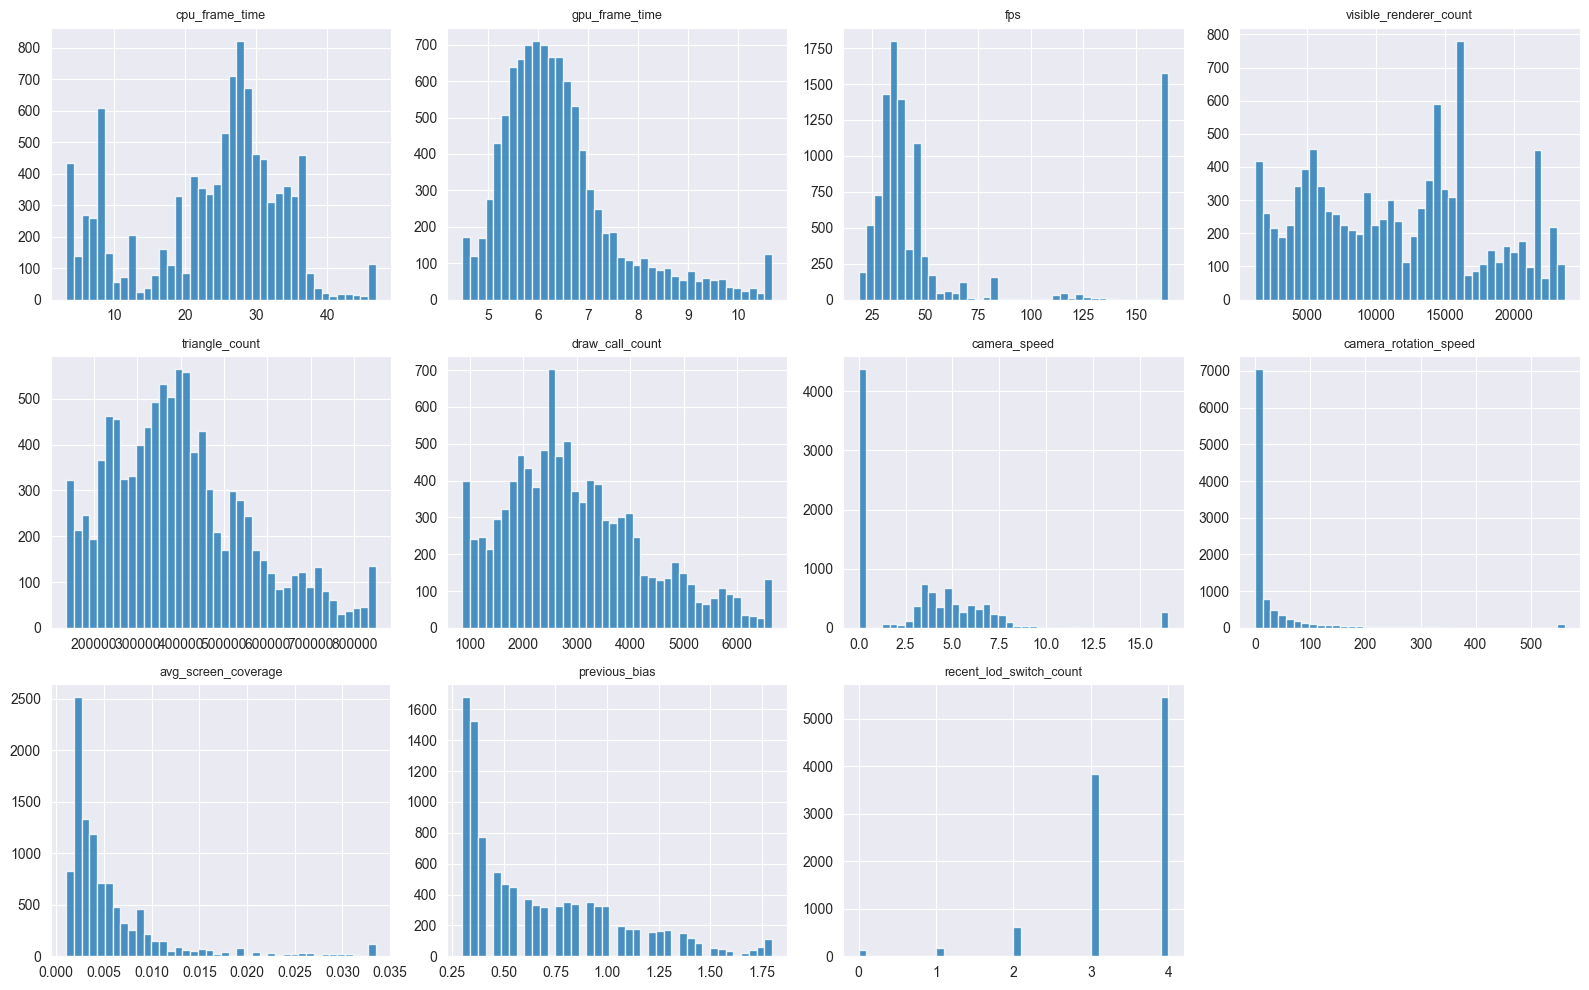

Final rows: 10237
Episodes  : 5


In [7]:
# Build scaler from cleaned native Stage 4 rollouts only.
X_raw = df_clean[FEATURE_COLS].values.astype(np.float32)

if X_raw.shape[0] == 0:
    raise ValueError('No samples available for scaling')

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

zero_scale = [
    (name, float(scale))
    for name, scale in zip(FEATURE_COLS, scaler.scale_)
    if scale < 1e-8
]
if zero_scale:
    raise ValueError(f'Zero-scale features detected: {zero_scale}')

scaler_data = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}

scaler_path = MODEL_DIR / 'rl_scaler_constants.json'
with open(scaler_path, 'w', encoding='utf-8') as f:
    json.dump(scaler_data, f, indent=2)

print('Scaling OK:', X_scaled.shape)
print('Saved:', scaler_path)

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    col_data = df_clean[col]
    clipped = col_data.clip(
        lower=col_data.quantile(0.01),
        upper=col_data.quantile(0.99)
    )
    axes[i].hist(clipped, bins=40, alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()

print('Final rows:', len(df_clean))
print('Episodes  :', df_clean['episode'].nunique())


## 4. Reward Computation

**Improvement-based reward** (fixes always-negative policy collapse):
```
r_t = (gpu_prev - gpu_t)                   # positive when GPU time decreases
    + BONUS_SCALE * (gpu_t <= T_TARGET)    # bonus for staying under budget
```
Switch penalty removed (`GAMMA_W=0`): penalising switches caused policy inaction.


In [8]:
# IMPROVEMENT-BASED REWARD
# r_t = (gpu_prev - gpu_t) + BONUS_SCALE * (gpu_t <= T_TARGET)
#
# Reference: Stage_4_rl_failure_diagnosis_and_fix.md sections 4-12.

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)

gpu      = df_clean['gpu_frame_time'].values.astype('float32')
gpu_prev = (
    df_clean.groupby('episode')['gpu_frame_time']
    .shift(1)
    .fillna(df_clean['gpu_frame_time'])  # first frame: no improvement signal
    .values.astype('float32')
)

r_improvement = gpu_prev - gpu
r_bonus       = (gpu <= T_TARGET).astype('float32') * BONUS_SCALE
rewards       = np.clip(r_improvement + r_bonus, -REWARD_CLIP, REWARD_CLIP).astype('float32')

if len(rewards) == 0:
    raise ValueError('rewards is empty -- df_clean is empty')

pos_pct = float((rewards > 0).mean() * 100)
print(f'Reward | mean={rewards.mean():.4f} std={rewards.std():.4f} '
      f'min={rewards.min():.4f} max={rewards.max():.4f}')
print(f'Positive steps: {(rewards > 0).sum():,}/{len(rewards):,} ({pos_pct:.1f}%)')

if pos_pct < 1.0:
    raise ValueError(
        f'Only {pos_pct:.1f}% positive rewards -- check GPU data quality.\n'
        'Ensure training_data_*.csv has valid per-frame gpu_frame_time_ms values.'
    )

df_clean = df_clean.copy()
df_clean['reward'] = rewards


Reward | mean=0.0159 std=1.7929 min=-5.0000 max=5.0000
Positive steps: 5,185/10,237 (50.6%)


## 5. Policy Network
Deterministic deployment policy MLP.
- **Input**: 11 normalized state features
- **Output**: action mean `mu` (scalar) bounded to the bootstrap support band `[-0.06, +0.06]` for fallback-policy training
- **Training log-prob sigma**: fixed constant `TRAIN_SIGMA` used only inside the REINFORCE loss
- ONNX exports only `mu` — Unity `RLPolicyController` reads `output[0]` deterministically


In [9]:
class PolicyMLP(nn.Module):
    """Stage 4 bootstrap policy: outputs action mean mu within the observed fallback support band."""
    def __init__(self, input_dim, h1, h2, h3, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),        nn.GELU(),
            nn.Linear(h3, 1),
            nn.Tanh()
        )
        self.action_scale = ACTION_HEAD_SCALE

    def forward(self, x):
        return self.net(x) * self.action_scale


## 6. Hyperparameter Tuning (Optuna)


### Returns and Train/Val Split
Discounted returns `G_t` computed per episode, then normalized globally.


In [10]:
# REINFORCE Returns

if len(df_clean) == 0:
    raise ValueError('df_clean is empty')
if 'reward' not in df_clean.columns:
    raise ValueError("'reward' column missing -- run Reward Computation cell first")

pos_pct = float((df_clean['reward'] > 0).mean() * 100)
if pos_pct < 1.0:
    raise ValueError(f'Only {pos_pct:.1f}% positive rewards -- check reward cell')

def compute_returns(rewards_ep, gamma):
    G = np.zeros_like(rewards_ep, dtype='float32')
    running = 0.0
    for t in reversed(range(len(rewards_ep))):
        running = float(rewards_ep[t]) + gamma * running
        G[t] = running
    return G

df_clean = df_clean.sort_values(['episode', 'step']).reset_index(drop=True)
returns_list = []
for _, grp in df_clean.groupby('episode', sort=False):
    returns_list.append(compute_returns(grp['reward'].values, GAMMA_RL))

df_clean['G_t'] = np.concatenate(returns_list)
G_mean = df_clean['G_t'].mean()
G_std  = df_clean['G_t'].std() + 1e-8
df_clean['G_t_norm'] = (df_clean['G_t'] - G_mean) / G_std

print(f'Returns shape: {df_clean["G_t_norm"].shape}')
print(f'G_t   | mean={df_clean["G_t"].mean():.4f} std={df_clean["G_t"].std():.4f}')
print(f'G_norm| mean={df_clean["G_t_norm"].mean():.4f} std={df_clean["G_t_norm"].std():.4f}')


Returns shape: (10237,)
G_t   | mean=1.6799 std=5.6043
G_norm| mean=-0.0000 std=1.0000


Quick trials to find the best architecture and learning rate for the deployable `mu` policy.
The objective combines REINFORCE validation loss with action-fit and saturation penalties,
which is more faithful to the Stage 4 runtime than tuning raw loss alone.

In [11]:
from sklearn.model_selection import GroupShuffleSplit
import logging
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

X_all = X_scaled
A_all = df_clean['action_delta'].values.astype('float32')
G_all = df_clean['G_t_norm'].values.astype('float32')

group_col = 'source_file' if 'source_file' in df_clean.columns and df_clean['source_file'].nunique() >= 2 else 'episode'
groups = df_clean[group_col].astype(str).values
unique_groups = pd.Index(pd.Series(groups).unique())
if len(unique_groups) < 2:
    raise ValueError(f'Need at least 2 unique {group_col} groups for a holdout split; found {len(unique_groups)}.')

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=VAL_GROUP_FRAC,
    random_state=RANDOM_SEED
)
train_idx, val_idx = next(splitter.split(X_all, A_all, groups=groups))

X_tr, X_val = X_all[train_idx], X_all[val_idx]
A_tr, A_val = A_all[train_idx], A_all[val_idx]
G_tr, G_val = G_all[train_idx], G_all[val_idx]
df_train = df_clean.iloc[train_idx].copy()
df_val = df_clean.iloc[val_idx].copy()

print(f'Holdout split uses: {group_col}')
print(f'Train groups      : {df_train[group_col].nunique()}')
print(f'Val groups        : {df_val[group_col].nunique()}')
print(f'Train rows        : {len(df_train):,}')
print(f'Val rows          : {len(df_val):,}')

X_tr_t  = torch.tensor(X_tr, dtype=torch.float32, device=device)
A_tr_t  = torch.tensor(A_tr, dtype=torch.float32, device=device)
G_tr_t  = torch.tensor(G_tr, dtype=torch.float32, device=device)
X_val_t = torch.tensor(X_val, dtype=torch.float32, device=device)
A_val_t = torch.tensor(A_val, dtype=torch.float32, device=device)
G_val_t = torch.tensor(G_val, dtype=torch.float32, device=device)

ACTION_SUPPORT = np.array(sorted(df_clean['action_delta'].dropna().unique().tolist()), dtype=np.float32)
BOOTSTRAP_ACTION_LIMIT = float(np.max(np.abs(ACTION_SUPPORT))) if ACTION_SUPPORT.size else 0.0
SOFT_SUPPORT_LIMIT = max(DEAD_ZONE, ACTION_HEAD_SCALE - SUPPORT_MARGIN)

print(f'Observed rollout action support: {ACTION_SUPPORT.tolist()}')
print(f'Observed support abs max      : +/-{BOOTSTRAP_ACTION_LIMIT:.3f}')
print(f'Deployable action envelope    : +/-{ACTION_HEAD_SCALE:.3f}')
print(f'Soft support warning limit    : +/-{SOFT_SUPPORT_LIMIT:.3f}')


def linear_schedule(start, end, progress):
    progress = float(np.clip(progress, 0.0, 1.0))
    return start + (end - start) * progress


def iter_sequence_groups(df_split):
    sort_cols = [group_col, 'step'] if group_col in df_split.columns else ['episode', 'step']
    for group_name, grp in df_split.sort_values(sort_cols).groupby(group_col, sort=False):
        yield group_name, grp


def apply_runtime_guardrails_np(raw_mu, start_bias):
    raw_mu = np.clip(np.asarray(raw_mu, dtype=np.float32), -ACTION_HEAD_SCALE, ACTION_HEAD_SCALE)
    applied = np.zeros_like(raw_mu, dtype=np.float32)
    bias = float(start_bias)
    frames_since_switch = DWELL_FRAMES

    for i, delta in enumerate(raw_mu):
        if abs(delta) < DEAD_ZONE:
            frames_since_switch += 1
            continue

        if frames_since_switch < DWELL_FRAMES:
            frames_since_switch += 1
            continue

        new_bias = float(np.clip(bias + float(delta), BIAS_MIN, BIAS_MAX))
        actual = new_bias - bias
        if abs(actual) < DEAD_ZONE:
            bias = new_bias
            frames_since_switch += 1
            continue

        applied[i] = actual
        bias = new_bias
        frames_since_switch = 0

    return applied


def build_deployment_frame(model, df_split):
    rows = []
    model.eval()
    with torch.no_grad():
        for _, grp in iter_sequence_groups(df_split):
            X_seq = scaler.transform(grp[FEATURE_COLS].values.astype(np.float32)).astype(np.float32)
            X_seq_t = torch.tensor(X_seq, dtype=torch.float32, device=device)
            raw_mu = model(X_seq_t).squeeze(1).detach().cpu().numpy().astype(np.float32)
            start_bias = float(grp['previous_bias'].iloc[0]) if 'previous_bias' in grp.columns else 1.0
            applied_mu = apply_runtime_guardrails_np(raw_mu, start_bias)

            part = grp[['episode', 'step', 'gpu_frame_time', 'action_delta']].copy()
            part['raw_mu'] = raw_mu
            part['applied_mu'] = applied_mu
            rows.append(part)

    if not rows:
        return pd.DataFrame(columns=['episode', 'step', 'gpu_frame_time', 'action_delta', 'raw_mu', 'applied_mu'])
    return pd.concat(rows, ignore_index=True)


def deployment_metrics(model, df_split):
    deploy_df = build_deployment_frame(model, df_split)
    if deploy_df.empty:
        return {
            'deploy_mae': np.nan,
            'deploy_active_pct': np.nan,
            'deploy_std': np.nan,
        }

    actual = deploy_df['action_delta'].values.astype(np.float32)
    applied = deploy_df['applied_mu'].values.astype(np.float32)
    return {
        'deploy_mae': float(np.mean(np.abs(applied - actual))),
        'deploy_active_pct': float((np.abs(applied) > 1e-6).mean() * 100.0),
        'deploy_std': float(np.std(applied)),
    }


def reinforce_loss(model, X, A, G, progress=1.0):
    mu = model(X).squeeze(1)
    sigma = torch.full_like(mu, TRAIN_SIGMA)
    dist = Normal(mu, sigma)

    pg_loss = -(G * dist.log_prob(A)).mean()

    bc_weight = torch.where(
        A.abs() > DEAD_ZONE,
        torch.full_like(A, NONZERO_BC_WEIGHT),
        torch.ones_like(A)
    )
    bc_loss = (bc_weight * F.smooth_l1_loss(mu, A, reduction='none')).mean()

    support_loss = ((mu.abs() - SOFT_SUPPORT_LIMIT).clamp(min=0.0) ** 2).mean()
    sat_loss = ((mu.abs() - SAT_WARN_THRESHOLD).clamp(min=0.0) ** 2).mean()
    pos_sat_loss = ((mu - SAT_WARN_THRESHOLD).clamp(min=0.0) ** 2).mean()
    entropy = dist.entropy().mean()

    bc_coef = linear_schedule(BC_COEF_START, BC_COEF_END, progress)
    support_coef = linear_schedule(SUPPORT_COEF_START, SUPPORT_COEF_END, progress)

    return (
        PG_COEF * pg_loss
        + bc_coef * bc_loss
        + support_coef * support_loss
        + SAT_COEF * sat_loss
        + POS_SAT_COEF * pos_sat_loss
        - ENTROPY_COEF * entropy
    )


def eval_metrics(model, X, A, G, df_split, progress=1.0):
    model.eval()
    with torch.no_grad():
        mu = model(X).squeeze(1)
        val_loss = reinforce_loss(model, X, A, G, progress=progress).item()
        mae = torch.mean(torch.abs(mu - A)).item()
        support_viol_pct = torch.mean((mu.abs() > SOFT_SUPPORT_LIMIT).float()).item() * 100.0
        sat_pct = torch.mean((mu.abs() >= SAT_WARN_THRESHOLD).float()).item() * 100.0
        pos_sat_pct = torch.mean((mu >= SAT_WARN_THRESHOLD).float()).item() * 100.0
        neg_sat_pct = torch.mean((mu <= -SAT_WARN_THRESHOLD).float()).item() * 100.0
        zero_pct = torch.mean((mu.abs() < 0.005).float()).item() * 100.0

    deploy = deployment_metrics(model, df_split)
    return (
        val_loss,
        mae,
        support_viol_pct,
        sat_pct,
        pos_sat_pct,
        neg_sat_pct,
        zero_pct,
        deploy['deploy_mae'],
        deploy['deploy_active_pct'],
    )


def run_trial(h1, h2, h3, lr, dropout, epochs=40):
    model_trial = PolicyMLP(FEATURE_COUNT, h1, h2, h3, dropout).to(device)
    optimizer = optim.AdamW(model_trial.parameters(), lr=lr)
    n = len(X_tr_t)

    for epoch in range(epochs):
        progress = epoch / max(epochs - 1, 1)
        model_trial.train()
        idx = torch.randperm(n)

        for start in range(0, n, BATCH_SIZE):
            b = idx[start:start + BATCH_SIZE]
            optimizer.zero_grad()
            loss = reinforce_loss(model_trial, X_tr_t[b], A_tr_t[b], G_tr_t[b], progress=progress)
            loss.backward()
            nn.utils.clip_grad_norm_(model_trial.parameters(), GRAD_CLIP)
            optimizer.step()

    val_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct, deploy_mae, deploy_active_pct = eval_metrics(
        model_trial,
        X_val_t,
        A_val_t,
        G_val_t,
        df_val,
        progress=1.0,
    )

    score = val_loss + 0.35 * deploy_mae + 0.02 * sat_pct + 0.05 * pos_sat_pct
    logging.info(
        f'  val_loss={val_loss:.4f} mae={mae:.4f} deploy_mae={deploy_mae:.4f} '
        f'support%={support_viol_pct:.2f} sat%={sat_pct:.2f} '
        f'pos_sat%={pos_sat_pct:.2f} neg_sat%={neg_sat_pct:.2f} '
        f'zero%={zero_pct:.2f} deploy_active%={deploy_active_pct:.2f} score={score:.4f}'
    )
    return score


def objective(trial):
    h1 = trial.suggest_categorical('h1', [128, 256, 512])
    h2 = trial.suggest_categorical('h2', [64, 128, 256])
    h3 = trial.suggest_categorical('h3', [32, 64, 128])
    lr = trial.suggest_float('lr', 5e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout', 0.05, 0.30)
    return run_trial(h1, h2, h3, lr, dropout)


study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=5)

logging.info(f'Best objective : {study.best_value:.6f}')
logging.info(f'Best params    : {study.best_params}')


Holdout split uses: source_file
Train groups      : 8
Val groups        : 3
Train rows        : 7,166
Val rows          : 3,071
Observed rollout action support: [-0.05000000074505806, 0.0, 0.05000000074505806]
Observed support abs max      : +/-0.050
Deployable action envelope    : +/-0.200
Soft support warning limit    : +/-0.180


[2026-04-04 19:58:53,060] INFO -   val_loss=-0.3086 mae=0.1790 deploy_mae=0.0066 support%=88.86 sat%=88.70 pos_sat%=0.00 neg_sat%=88.70 zero%=3.45 deploy_active%=0.55 score=1.4677
[2026-04-04 19:59:00,221] INFO -   val_loss=-0.3087 mae=0.1797 deploy_mae=0.0066 support%=89.29 sat%=89.22 pos_sat%=0.00 neg_sat%=89.22 zero%=4.01 deploy_active%=0.55 score=1.4781
[2026-04-04 19:59:07,399] INFO -   val_loss=-0.3069 mae=0.1802 deploy_mae=0.0073 support%=89.06 sat%=88.99 pos_sat%=88.99 neg_sat%=0.00 zero%=6.22 deploy_active%=0.94 score=5.9252
[2026-04-04 19:59:14,487] INFO -   val_loss=-0.3135 mae=0.1809 deploy_mae=0.0073 support%=89.09 sat%=88.99 pos_sat%=88.99 neg_sat%=0.00 zero%=4.10 deploy_active%=1.01 score=5.9186
[2026-04-04 19:59:21,563] INFO -   val_loss=-0.3155 mae=0.1803 deploy_mae=0.0074 support%=88.96 sat%=88.83 pos_sat%=88.83 neg_sat%=0.00 zero%=5.54 deploy_active%=1.34 score=5.9052
[2026-04-04 19:59:21,565] INFO - Best objective : 1.467735
[2026-04-04 19:59:21,565] INFO - Best par

## Optuna Result
(Populated after running the tuning cell above.)


## 7. Final REINFORCE Training

[2026-04-04 19:59:21,586] INFO - Best params loaded: {'h1': 512, 'h2': 128, 'h3': 32, 'lr': 0.0005848048320835059, 'dropout': 0.22852038097263333}
[2026-04-04 19:59:21,590] INFO - TRAINING START | epochs=150 lr=0.0005848 | fixed-sigma mu policy
[2026-04-04 19:59:21,787] INFO - Epoch 1/150 | train=-0.036276 | val=-0.083463 | mae=0.111745 | deploy_mae=0.006625 | support%=22.96 | sat%=15.43 | pos_sat%=0.00 | neg_sat%=15.43 | zero%=4.59 | deploy_active%=1.04 | bc=0.120 | support=0.250
[2026-04-04 19:59:21,987] INFO - Epoch 2/150 | train=-0.170336 | val=-0.256947 | mae=0.176303 | deploy_mae=0.007591 | support%=80.56 | sat%=72.97 | pos_sat%=0.00 | neg_sat%=72.97 | zero%=1.11 | deploy_active%=3.16 | bc=0.119 | support=0.248
[2026-04-04 19:59:22,180] INFO - Epoch 3/150 | train=-0.225392 | val=-0.285168 | mae=0.177564 | deploy_mae=0.007006 | support%=85.87 | sat%=84.79 | pos_sat%=0.00 | neg_sat%=84.79 | zero%=2.54 | deploy_active%=1.99 | bc=0.119 | support=0.247
[2026-04-04 19:59:22,379] INFO -

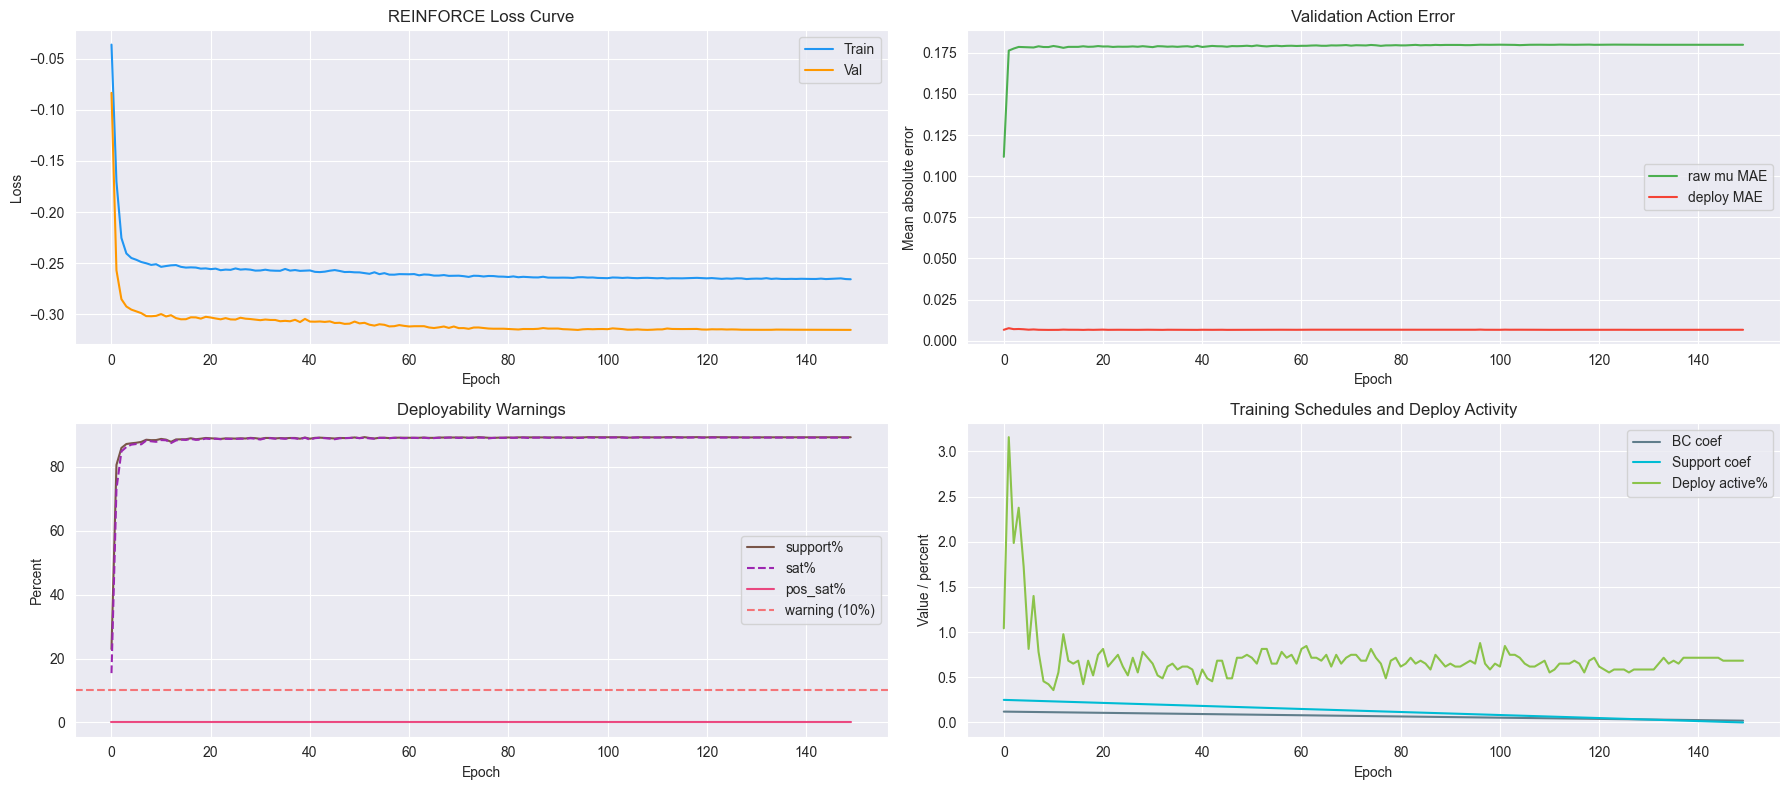

[2026-04-04 19:59:56,348] INFO - Final fixed training sigma: 0.1000
[2026-04-04 19:59:56,349] INFO - Final support violation rate: 89.22%
[2026-04-04 19:59:56,350] INFO - Final saturation rate: 89.09%
[2026-04-04 19:59:56,350] INFO - Final positive saturation rate: 0.00%
[2026-04-04 19:59:56,350] INFO - Final deploy MAE: 0.006632


In [12]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

bp = study.best_params
logging.info(f'Best params loaded: {bp}')

model = PolicyMLP(
    FEATURE_COUNT,
    h1=bp['h1'],
    h2=bp['h2'],
    h3=bp['h3'],
    dropout=bp['dropout']
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

EPOCHS = 150
history = {
    'train': [],
    'val': [],
    'mae': [],
    'deploy_mae': [],
    'support_pct': [],
    'sat_pct': [],
    'pos_sat_pct': [],
    'deploy_active_pct': [],
    'bc_coef': [],
    'support_coef': [],
}
n = len(X_tr_t)

logging.info(f'TRAINING START | epochs={EPOCHS} lr={bp["lr"]:.5g} | fixed-sigma mu policy')

for epoch in range(EPOCHS):
    progress = epoch / max(EPOCHS - 1, 1)
    bc_coef = linear_schedule(BC_COEF_START, BC_COEF_END, progress)
    support_coef = linear_schedule(SUPPORT_COEF_START, SUPPORT_COEF_END, progress)

    model.train()
    idx = torch.randperm(n)
    t_losses = []

    for start in range(0, n, BATCH_SIZE):
        b = idx[start:start + BATCH_SIZE]
        optimizer.zero_grad()
        loss = reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b], progress=progress)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        t_losses.append(loss.item())

    scheduler.step()

    metrics = eval_metrics(
        model,
        X_val_t,
        A_val_t,
        G_val_t,
        df_val,
        progress=progress,
    )
    v_loss, mae, support_viol_pct, sat_pct, pos_sat_pct, neg_sat_pct, zero_pct, deploy_mae, deploy_active_pct = metrics

    train_loss = float(np.mean(t_losses))
    history['train'].append(train_loss)
    history['val'].append(v_loss)
    history['mae'].append(mae)
    history['deploy_mae'].append(deploy_mae)
    history['support_pct'].append(support_viol_pct)
    history['sat_pct'].append(sat_pct)
    history['pos_sat_pct'].append(pos_sat_pct)
    history['deploy_active_pct'].append(deploy_active_pct)
    history['bc_coef'].append(bc_coef)
    history['support_coef'].append(support_coef)

    logging.info(
        f'Epoch {epoch + 1}/{EPOCHS} | train={train_loss:.6f} | val={v_loss:.6f} | '
        f'mae={mae:.6f} | deploy_mae={deploy_mae:.6f} | support%={support_viol_pct:.2f} | '
        f'sat%={sat_pct:.2f} | pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | '
        f'zero%={zero_pct:.2f} | deploy_active%={deploy_active_pct:.2f} | '
        f'bc={bc_coef:.3f} | support={support_coef:.3f}'
    )

    if epoch >= 10 and pos_sat_pct > 10.0:
        logging.warning(
            f'Epoch {epoch + 1}: pos_sat%={pos_sat_pct:.1f} > 10% - '
            'positive collapse detected; inspect diagnostics before export.'
        )

    if epoch >= 20 and deploy_mae > 0.08:
        logging.warning(
            f'Epoch {epoch + 1}: deploy_MAE={deploy_mae:.4f} > 0.08 - '
            'runtime guardrail mismatch still too high.'
        )

fig, axes = plt.subplots(2, 2, figsize=(18, 8))

ax = axes[0, 0]
ax.plot(history['train'], label='Train', color='#2196F3')
ax.plot(history['val'], label='Val', color='#FF9800')
ax.set_title('REINFORCE Loss Curve')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()

ax = axes[0, 1]
ax.plot(history['mae'], color='#4CAF50', label='raw mu MAE')
ax.plot(history['deploy_mae'], color='#F44336', label='deploy MAE')
ax.set_title('Validation Action Error')
ax.set_xlabel('Epoch')
ax.set_ylabel('Mean absolute error')
ax.legend()

ax = axes[1, 0]
ax.plot(history['support_pct'], color='#795548', label='support%')
ax.plot(history['sat_pct'], color='#9C27B0', linestyle='--', label='sat%')
ax.plot(history['pos_sat_pct'], color='#E91E63', alpha=0.8, label='pos_sat%')
ax.axhline(10.0, color='red', linestyle='--', alpha=0.5, label='warning (10%)')
ax.set_title('Deployability Warnings')
ax.set_xlabel('Epoch')
ax.set_ylabel('Percent')
ax.legend()

ax = axes[1, 1]
ax.plot(history['bc_coef'], color='#607D8B', label='BC coef')
ax.plot(history['support_coef'], color='#00BCD4', label='Support coef')
ax.plot(history['deploy_active_pct'], color='#8BC34A', label='Deploy active%')
ax.set_title('Training Schedules and Deploy Activity')
ax.set_xlabel('Epoch')
ax.set_ylabel('Value / percent')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)
plt.show()

final_support = history['support_pct'][-1]
final_sat = history['sat_pct'][-1]
final_pos_sat = history['pos_sat_pct'][-1]
final_deploy_mae = history['deploy_mae'][-1]
logging.info(f'Final fixed training sigma: {TRAIN_SIGMA:.4f}')
logging.info(f'Final support violation rate: {final_support:.2f}%')
logging.info(f'Final saturation rate: {final_sat:.2f}%')
logging.info(f'Final positive saturation rate: {final_pos_sat:.2f}%')
logging.info(f'Final deploy MAE: {final_deploy_mae:.6f}')

if final_pos_sat > 10.0:
    logging.warning('positive mu saturation too high - do not export without reviewing diagnostics')

if final_deploy_mae > 0.08:
    logging.warning('deploy MAE is still high - do not export without reviewing diagnostics')


## 8. Policy Diagnostics
These diagnostics are aligned to the actual Stage 4 bootstrap regime:
- rollout actions are quantized by `RLPolicyController` (`-0.05`, `0.0`, `+0.05` in the current data)
- Unity deploys only `mu`
- the key health checks are action-fit and avoidance of `+/-0.20` collapse

[2026-04-04 19:59:56,367] INFO - Model device: cuda:0
[2026-04-04 19:59:56,367] INFO - Input device: cuda:0
[2026-04-04 19:59:56,443] INFO - Fixed training sigma: 0.100000
[2026-04-04 19:59:56,444] INFO - Deployable action envelope: +/-0.200
[2026-04-04 19:59:56,444] INFO - Predicted mu stats | mean=-0.181311 | std=0.057802 | min=-0.200000 | max=0.050767
[2026-04-04 19:59:56,445] INFO - Action fit | raw_MAE=0.181751 | deploy_MAE=0.006379 | support%=90.38 | sat%=90.27 | pos_sat%=0.00 | neg_sat%=90.27 | zero%=5.02 | deploy_active%=0.50


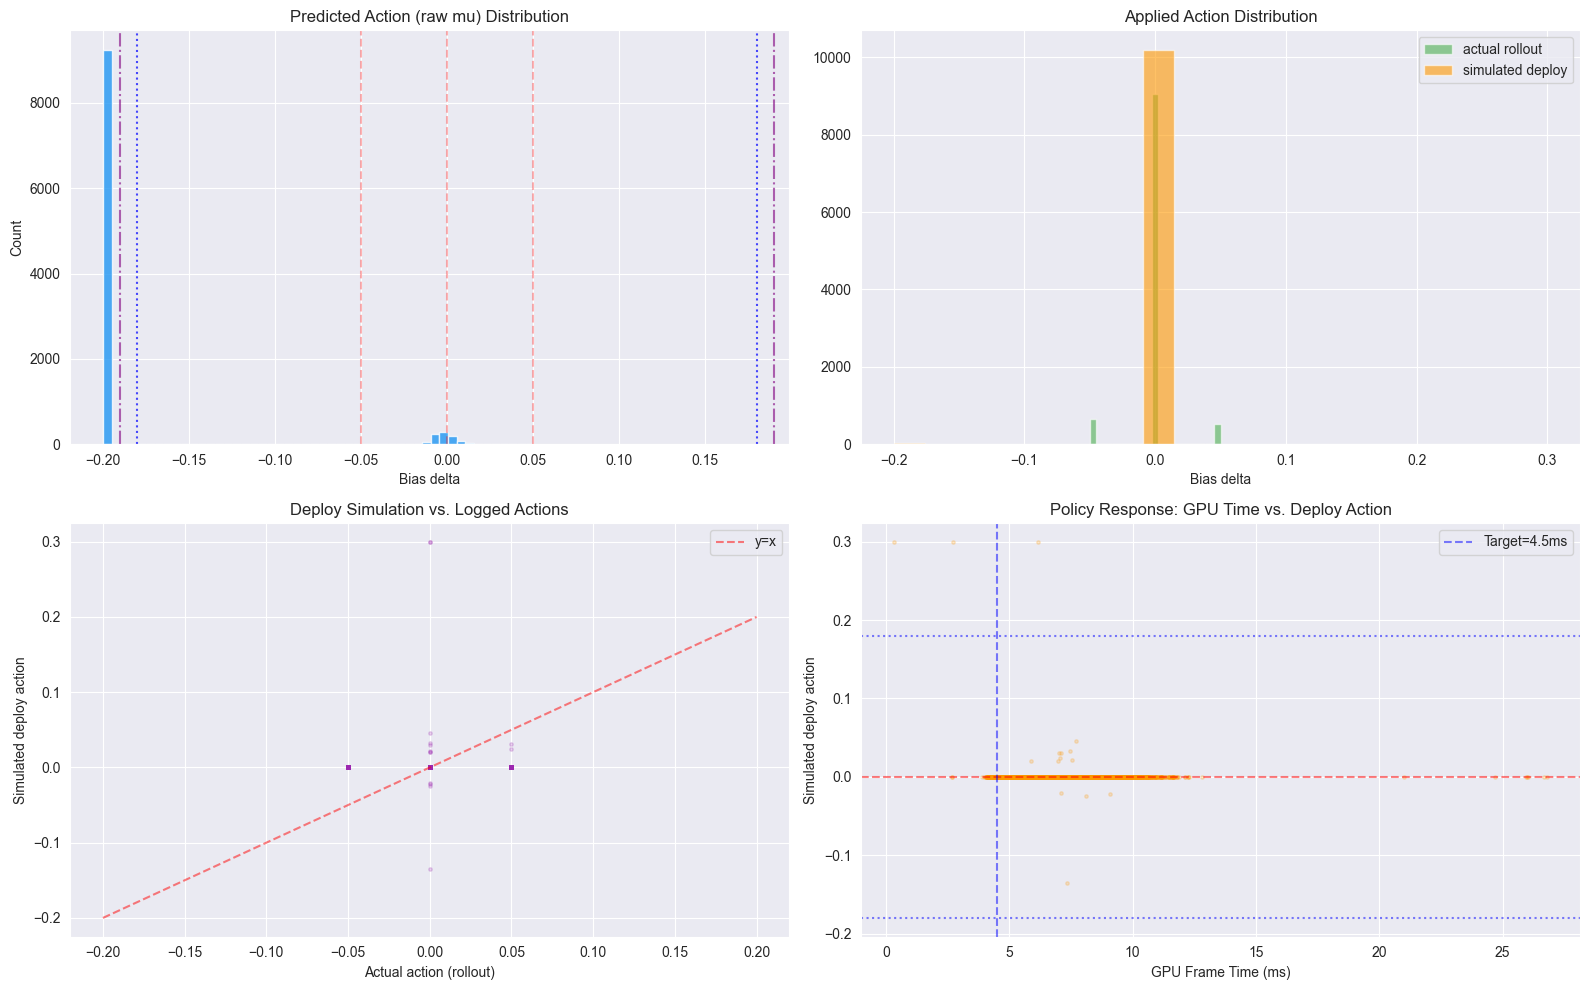

[2026-04-04 19:59:57,383] INFO - Saved: action_diagnostics.png


In [13]:
import logging
import torch

logging.basicConfig(
    level=logging.INFO,
    format='[%(asctime)s] %(levelname)s - %(message)s'
)

model = model.to(device)
for name, buf in model.named_buffers():
    model._buffers[name] = buf.to(device)

X_all_t = torch.tensor(X_scaled, dtype=torch.float32, device=device)

logging.info(f'Model device: {next(model.parameters()).device}')
logging.info(f'Input device: {X_all_t.device}')

model.eval()
with torch.no_grad():
    mu_all = model(X_all_t).cpu().numpy().flatten()

deployment_frame = build_deployment_frame(model, df_clean)
raw_mu_all = deployment_frame['raw_mu'].values.astype('float32')
applied_mu_all = deployment_frame['applied_mu'].values.astype('float32')
actual_actions = deployment_frame['action_delta'].values.astype('float32')

mae_all = float(np.mean(np.abs(raw_mu_all - actual_actions)))
deploy_mae_all = float(np.mean(np.abs(applied_mu_all - actual_actions)))
support_viol_pct = float((np.abs(raw_mu_all) > SOFT_SUPPORT_LIMIT).mean() * 100)
sat_pct = float((np.abs(raw_mu_all) >= SAT_WARN_THRESHOLD).mean() * 100)
pos_sat_pct = float((raw_mu_all >= SAT_WARN_THRESHOLD).mean() * 100)
neg_sat_pct = float((raw_mu_all <= -SAT_WARN_THRESHOLD).mean() * 100)
zero_pct = float((np.abs(raw_mu_all) < 0.005).mean() * 100)
deploy_active_pct = float((np.abs(applied_mu_all) > 1e-6).mean() * 100)

logging.info(f'Fixed training sigma: {TRAIN_SIGMA:.6f}')
logging.info(f'Deployable action envelope: +/-{ACTION_HEAD_SCALE:.3f}')
logging.info(
    f'Predicted mu stats | mean={raw_mu_all.mean():.6f} | std={raw_mu_all.std():.6f} | '
    f'min={raw_mu_all.min():.6f} | max={raw_mu_all.max():.6f}'
)
logging.info(
    f'Action fit | raw_MAE={mae_all:.6f} | deploy_MAE={deploy_mae_all:.6f} | '
    f'support%={support_viol_pct:.2f} | sat%={sat_pct:.2f} | '
    f'pos_sat%={pos_sat_pct:.2f} | neg_sat%={neg_sat_pct:.2f} | '
    f'zero%={zero_pct:.2f} | deploy_active%={deploy_active_pct:.2f}'
)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

ax = axes[0, 0]
ax.hist(raw_mu_all, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
for v in sorted(np.unique(actual_actions)):
    ax.axvline(v, color='red', linestyle='--', alpha=0.3)
ax.axvline(SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.axvline(-SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.7)
ax.axvline(SAT_WARN_THRESHOLD, color='purple', linestyle='-.', alpha=0.6)
ax.axvline(-SAT_WARN_THRESHOLD, color='purple', linestyle='-.', alpha=0.6)
ax.set_title('Predicted Action (raw mu) Distribution')
ax.set_xlabel('Bias delta')
ax.set_ylabel('Count')

ax = axes[0, 1]
ax.hist(actual_actions, bins=21, color='#4CAF50', alpha=0.6, edgecolor='white', label='actual rollout')
ax.hist(applied_mu_all, bins=21, color='#FF9800', alpha=0.6, edgecolor='white', label='simulated deploy')
ax.set_title('Applied Action Distribution')
ax.set_xlabel('Bias delta')
ax.legend()

ax = axes[1, 0]
ax.scatter(actual_actions[:2000], applied_mu_all[:2000], alpha=0.2, s=6, color='#9C27B0')
ax.plot([-ACTION_HEAD_SCALE, ACTION_HEAD_SCALE], [-ACTION_HEAD_SCALE, ACTION_HEAD_SCALE], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Actual action (rollout)')
ax.set_ylabel('Simulated deploy action')
ax.set_title('Deploy Simulation vs. Logged Actions')
ax.legend()

ax = axes[1, 1]
ax.scatter(
    deployment_frame['gpu_frame_time'].values[:3000],
    applied_mu_all[:3000],
    alpha=0.2,
    s=6,
    color='#FF9800'
)
ax.axhline(0, color='red', linestyle='--', alpha=0.5)
ax.axhline(SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.axhline(-SOFT_SUPPORT_LIMIT, color='blue', linestyle=':', alpha=0.5)
ax.axvline(T_TARGET, color='blue', linestyle='--', alpha=0.5, label=f'Target={T_TARGET}ms')
ax.set_xlabel('GPU Frame Time (ms)')
ax.set_ylabel('Simulated deploy action')
ax.set_title('Policy Response: GPU Time vs. Deploy Action')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'action_diagnostics.png', dpi=150)
plt.show()
logging.info('Saved: action_diagnostics.png')

if pos_sat_pct > 10.0:
    logging.warning('positive mu saturation too high - do not export without reviewing diagnostics')

if deploy_mae_all > 0.08:
    logging.warning('deploy MAE is still high - do not export without reviewing diagnostics')


## 9. ONNX Export
Exports the deployable deterministic mean policy `mu` only. Unity `RLPolicyController` reads `output[0]` as the action delta.

In [14]:
pip install onnxruntime-gpu

Note: you may need to restart the kernel to use updated packages.


In [15]:
import onnxruntime as ort
print(ort.__version__)

1.24.4


In [16]:
# Quality gate before export -- block degenerate feature sets or clearly undeployable policies
nonzero_pct = (df_clean[FEATURE_COLS] != 0).mean() * 100
zero_features = nonzero_pct[nonzero_pct < 1.0].index.tolist()
if zero_features:
    print(f'BLOCKED: {len(zero_features)} features are near-all-zero:')
    for fn in zero_features:
        print(f'  {fn}: {nonzero_pct[fn]:.1f}% non-zero')
    raise RuntimeError('ONNX export blocked -- near-zero feature columns detected.')

if 'deployment_frame' not in globals():
    raise RuntimeError('Run the diagnostics cell before export so deployability checks are available.')

if deploy_mae_all > 0.08:
    raise RuntimeError(
        f'ONNX export blocked -- deploy_MAE={deploy_mae_all:.4f} exceeds the audit safety gate (0.08).'
    )

if pos_sat_pct > 10.0:
    raise RuntimeError(
        f'ONNX export blocked -- positive saturation {pos_sat_pct:.2f}% exceeds the audit safety gate (10%).'
    )

print('Quality gate passed. Proceeding with ONNX export.')


Quality gate passed. Proceeding with ONNX export.


In [17]:
onnx_path = MODEL_DIR / 'rl_policy_stage4.onnx'
export_model = model.cpu().eval()
dummy_input  = torch.zeros(1, FEATURE_COUNT, dtype=torch.float32)

torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f'ONNX exported → {onnx_path}')

import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'input': dummy_input.numpy()})[0]
print(f'ONNX output shape: {out.shape} | value: {out[0,0]:.6f}')
assert out.shape == (1, 1), f'Expected (1,1), got {out.shape}'
print('ONNX validation OK.')
print()
print(f'Next step: assign {onnx_path.name} to RLPolicyController.OnnxAsset in Unity.')


ONNX exported → C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
ONNX output shape: (1, 1) | value: -0.200000
ONNX validation OK.

Next step: assign rl_policy_stage4.onnx to RLPolicyController.OnnxAsset in Unity.


## 10. Output Summary

In [18]:
print('Training complete.')
print(f'  Final val loss      : {history["val"][-1]:.4f}')
print(f'  Final val MAE       : {history["mae"][-1]:.4f}')
print(f'  Final deploy MAE    : {history["deploy_mae"][-1]:.4f}')
print(f'  Final support rate  : {history["support_pct"][-1]:.2f}%')
print(f'  Final sat rate      : {history["sat_pct"][-1]:.2f}%')
print(f'  Final deploy active : {history["deploy_active_pct"][-1]:.2f}%')
print(f'  Action head scale   : +/-{ACTION_HEAD_SCALE:.2f}')
print(f'  Training sigma      : fixed {TRAIN_SIGMA:.3f}')


Training complete.
  Final val loss      : -0.3152
  Final val MAE       : 0.1799
  Final deploy MAE    : 0.0066
  Final support rate  : 89.22%
  Final sat rate      : 89.09%
  Final deploy active : 0.68%
  Action head scale   : +/-0.20
  Training sigma      : fixed 0.100
